# EDA: `games`
 
**Descripción:** Lista de juegos con información general: título, desarrolladores, publishers, géneros, idiomas y fecha de lanzamiento.

| Columna | Tipo | Descripción |
|---|---|---|
| `gameid` | int | ID único del juego en Steam |
| `title` | str | Nombre completo del juego |
| `developers` | list (str) | Lista de desarrolladores |
| `publishers` | list (str) | Lista de publishers |
| `genres` | list (str) | Géneros asignados |
| `supported_languages` | list (str) | Idiomas disponibles |
| `release_date` | date | Fecha de lanzamiento |

---

##  Imports y configuración de estilo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes, ha='center', fontsize=9, color=MUTED)

##  Carga y preprocesamiento

Las columnas de listas (`developers`, `publishers`, `genres`, `supported_languages`) vienen como strings en el CSV.  
Se parsean con `ast.literal_eval` y se crean columnas auxiliares `*_list` y `*_count` para facilitar el análisis.  
También se extrae `release_year` y `release_month` de la fecha de lanzamiento.

In [2]:
df_raw = pd.read_csv('Datos/games.csv') 
df = df_raw.copy()
n_rows, n_cols = df.shape
print(f"Shape: {n_rows:,} filas × {n_cols} columnas")
df_raw.head(3)

Shape: 98,248 filas × 7 columnas


,gameid,title,developers,publishers,genres,supported_languages,release_date
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,2024-10-21
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,2024-10-17
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,2024-10-13


In [3]:
def safe_parse_list(val):
    """Parsea strings con formato de lista Python. Retorna [] si está vacío o es NaN."""
    if pd.isna(val) or str(val).strip() == '':
        return []
    try:
        result = ast.literal_eval(val)
        if isinstance(result, list):
            return result
    except:
        pass
    return [v.strip().strip("'\"") for v in str(val).split(',') if v.strip()]

LIST_COLS = ['developers', 'publishers', 'genres', 'supported_languages']
for col in LIST_COLS:
    df[col + '_list']  = df[col].apply(safe_parse_list)
    df[col + '_count'] = df[col + '_list'].apply(len)

df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['is_playtest']   = df['title'].str.contains('Playtest', case=False, na=False)

print("Columnas disponibles:", df.columns.tolist())

Columnas disponibles: ['gameid', 'title', 'developers', 'publishers', 'genres', 'supported_languages', 'release_date', 'developers_list', 'developers_count', 'publishers_list', 'publishers_count', 'genres_list', 'genres_count', 'supported_languages_list', 'supported_languages_count', 'release_year', 'release_month', 'is_playtest']


### Series precalculadas

Se hace `explode()` en cada columna de listas para poder contar y rankear los valores individuales (géneros, idiomas, devs, publishers) de forma eficiente.

In [4]:
dev_series   = df.explode('developers_list')['developers_list'].dropna()
dev_series   = dev_series[dev_series != '']
pub_series   = df.explode('publishers_list')['publishers_list'].dropna()
pub_series   = pub_series[pub_series != '']
genre_series = df.explode('genres_list')['genres_list'].dropna()
genre_series = genre_series[genre_series != '']
lang_series  = df.explode('supported_languages_list')['supported_languages_list'].dropna()
lang_series  = lang_series[lang_series != '']

top_genres = genre_series.value_counts().head(20)
top_langs  = lang_series.value_counts().head(20)
top_devs   = dev_series.value_counts().head(15)
top_pubs   = pub_series.value_counts().head(15)

year_counts = df['release_year'].value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 2000) & (year_counts.index <= 2025)]

games_per_dev         = df[df['developers_count'] > 0]['developers_count']
genre_counts_per_game = df['genres_count']
month_release         = df.dropna(subset=['release_month'])['release_month'].value_counts().sort_index()
MONTH_NAMES           = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

---
##  Análisis de valores faltantes

Las columnas de listas (`developers`, `publishers`, `genres`, `supported_languages`) pueden estar vacías de dos formas:
- `NaN` real (campo ausente)
- String vacío `''` (campo presente pero sin valor)

Ambos casos se tratan como faltantes. La estrategia adoptada es **no eliminar filas**, sino conservar las listas vacías `[]` y usar el flag `*_count == 0` para identificarlas.


In [5]:
missing  = df_raw.isnull() | (df_raw.apply(lambda col: col.astype(str).str.strip() == ''))
miss_pct = (missing.mean() * 100).round(2)
miss_cnt = missing.sum()

print("Porcentaje de valores faltantes por columna:")
pd.DataFrame({'count': miss_cnt, 'pct (%)': miss_pct}).sort_values('pct (%)', ascending=False)

Porcentaje de valores faltantes por columna:


,count,pct (%)
publishers,5941,6.05
developers,5559,5.66
genres,5549,5.65
supported_languages,5506,5.60
gameid,0,0.00
title,3,0.00
release_date,0,0.00


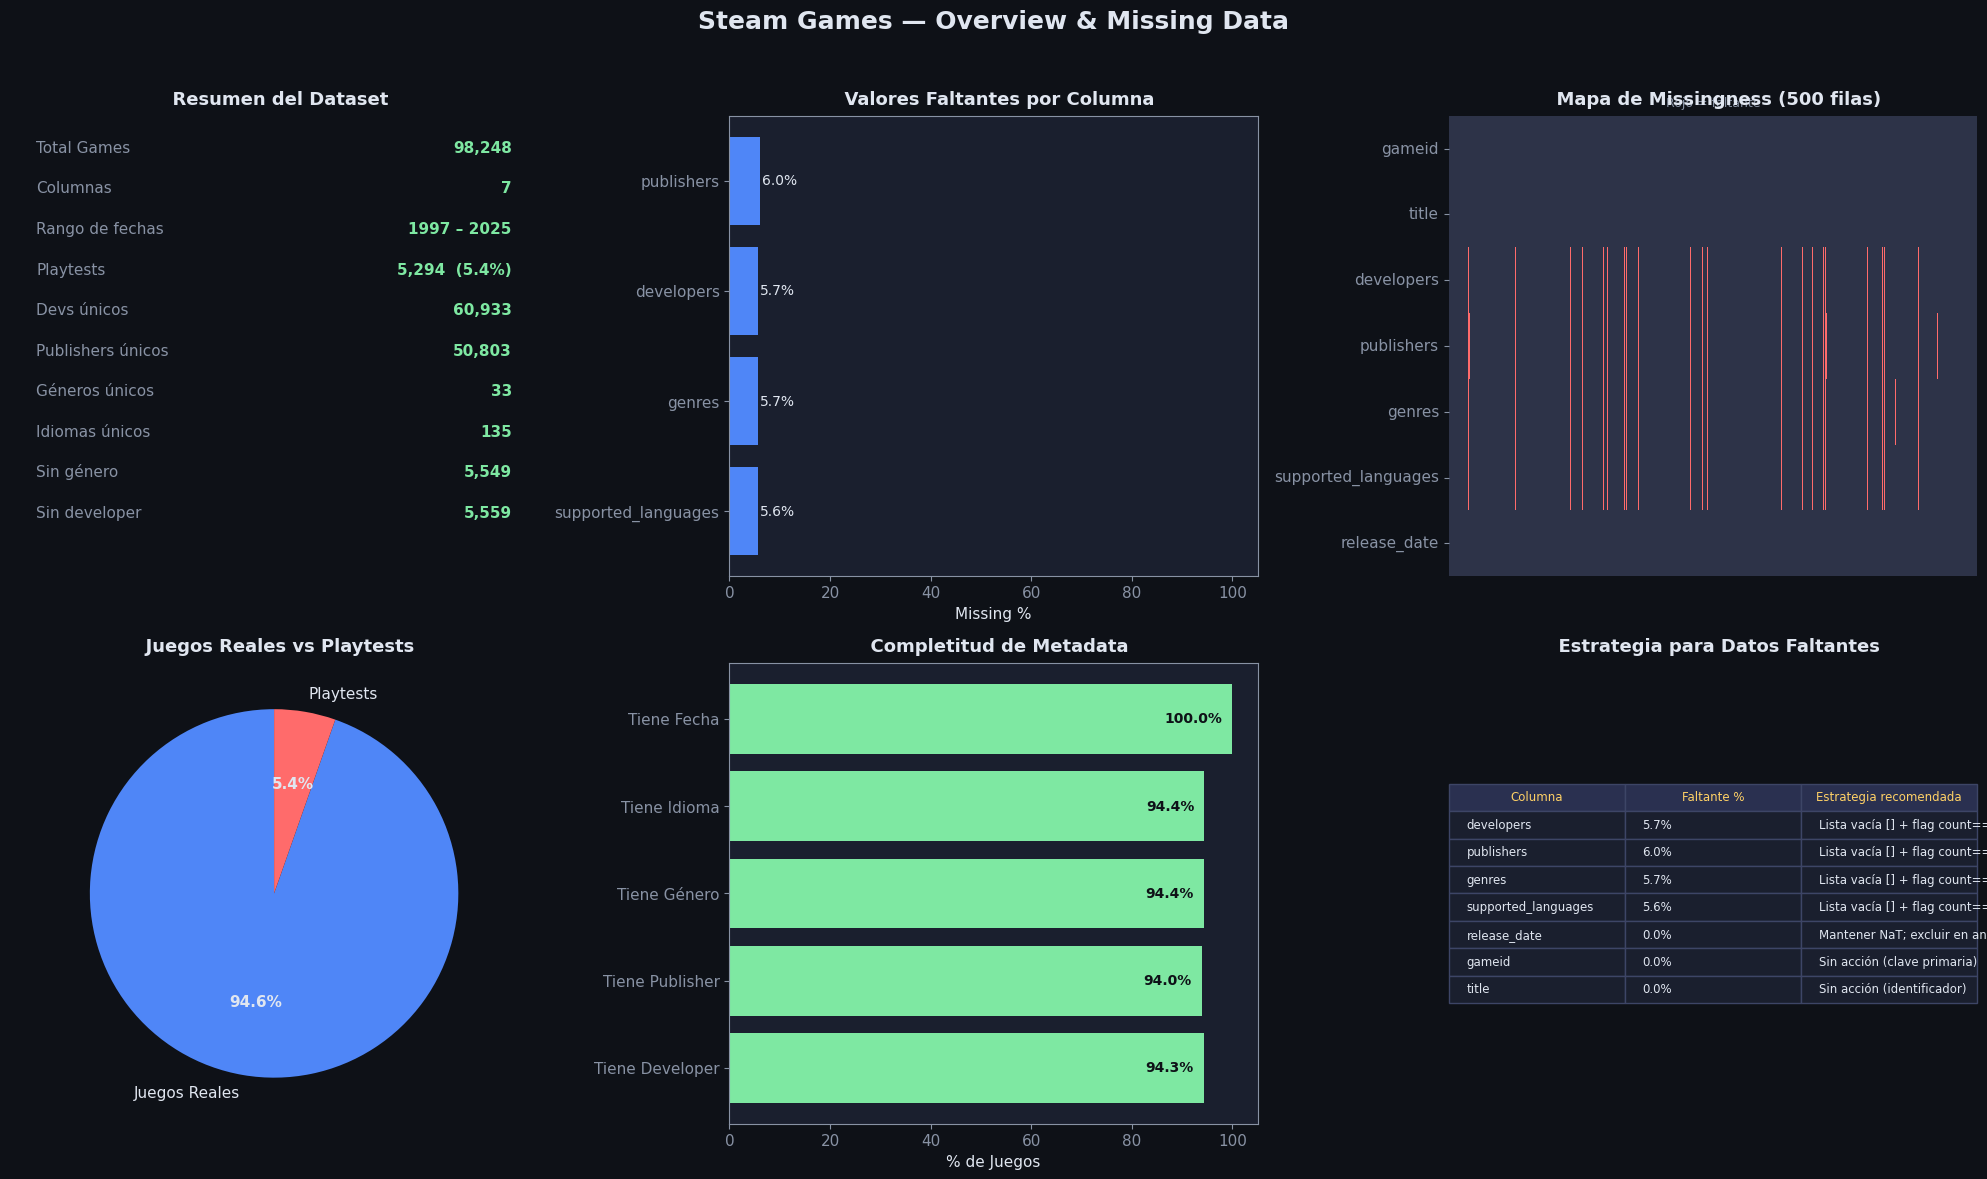

In [6]:
fig1, axes = plt.subplots(2, 3, figsize=(20, 12))
fig1.patch.set_facecolor(DARK_BG)
fig1.suptitle('Steam Games — Overview & Missing Data', fontsize=18, fontweight='bold', color=TEXT, y=0.98)


ax = axes[0, 0]
ax.set_facecolor(CARD_BG)
ax.axis('off')
summary_lines = [
    ('Total Games',       f'{n_rows:,}'),
    ('Columnas',          f'{n_cols}'),
    ('Rango de fechas',   f'{df["release_year"].min():.0f} – {df["release_year"].max():.0f}'),
    ('Playtests',         f'{df["is_playtest"].sum():,}  ({df["is_playtest"].mean()*100:.1f}%)'),
    ('Devs únicos',       f'{dev_series.nunique():,}'),
    ('Publishers únicos', f'{pub_series.nunique():,}'),
    ('Géneros únicos',    f'{genre_series.nunique():,}'),
    ('Idiomas únicos',    f'{lang_series.nunique():,}'),
    ('Sin género',        f'{(df["genres_count"]==0).sum():,}'),
    ('Sin developer',     f'{(df["developers_count"]==0).sum():,}'),
]
for i, (k, v) in enumerate(summary_lines):
    y = 0.92 - i * 0.088
    ax.text(0.05, y, k, transform=ax.transAxes, fontsize=11, color=MUTED)
    ax.text(0.95, y, v, transform=ax.transAxes, fontsize=11, color=ACCENT2, ha='right', fontweight='bold')
title_ax(ax, '  Resumen del Dataset')

ax = axes[0, 1]
cols_miss = miss_pct[miss_pct > 0].sort_values(ascending=True)
bars = ax.barh(cols_miss.index, cols_miss.values,
               color=[ACCENT3 if v > 50 else ACCENT4 if v > 20 else ACCENT1 for v in cols_miss.values])
for bar, val in zip(bars, cols_miss.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, color=TEXT)
ax.set_xlim(0, 105)
ax.set_xlabel('Missing %')
title_ax(ax, '  Valores Faltantes por Columna')


ax = axes[0, 2]
sample = df_raw.sample(min(500, n_rows), random_state=42)
miss_matrix = sample.isnull() | (sample.apply(lambda col: col.astype(str).str.strip() == ''))
sns.heatmap(miss_matrix.T, ax=ax, cbar=False, cmap=['#2d3348', ACCENT3], yticklabels=True, xticklabels=False)
title_ax(ax, '  Mapa de Missingness (500 filas)', 'Rojo = faltante')


ax = axes[1, 0]
vc = df['is_playtest'].value_counts()
wedges, texts, autotexts = ax.pie(
    [vc[False], vc[True]], labels=['Juegos Reales', 'Playtests'],
    autopct='%1.1f%%', colors=[ACCENT1, ACCENT3], startangle=90, textprops={'color': TEXT}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
title_ax(ax, '  Juegos Reales vs Playtests')

ax = axes[1, 1]
cats = ['Tiene Developer', 'Tiene Publisher', 'Tiene Género', 'Tiene Idioma', 'Tiene Fecha']
pcts = [
    (df['developers_count'] > 0).mean() * 100,
    (df['publishers_count'] > 0).mean() * 100,
    (df['genres_count'] > 0).mean() * 100,
    (df['supported_languages_count'] > 0).mean() * 100,
    df['release_date'].notna().mean() * 100,
]
bar_colors = [ACCENT2 if p >= 80 else ACCENT4 if p >= 50 else ACCENT3 for p in pcts]
bars = ax.barh(cats, pcts, color=bar_colors)
for bar, val in zip(bars, pcts):
    ax.text(val - 2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right', fontsize=10, color=DARK_BG, fontweight='bold')
ax.set_xlim(0, 105); ax.set_xlabel('% de Juegos')
title_ax(ax, '  Completitud de Metadata')

ax = axes[1, 2]
ax.axis('off')
strategy_data = [
    ['developers',          f'{miss_pct["developers"]:.1f}%',          'Lista vacía [] + flag count==0'],
    ['publishers',          f'{miss_pct["publishers"]:.1f}%',          'Lista vacía [] + flag count==0'],
    ['genres',              f'{miss_pct["genres"]:.1f}%',              'Lista vacía [] + flag count==0'],
    ['supported_languages', f'{miss_pct["supported_languages"]:.1f}%', 'Lista vacía [] + flag count==0'],
    ['release_date',        f'{miss_pct["release_date"]:.1f}%',        'Mantener NaT; excluir en análisis temporal'],
    ['gameid',              f'{miss_pct["gameid"]:.1f}%',              'Sin acción (clave primaria)'],
    ['title',               f'{miss_pct["title"]:.1f}%',               'Sin acción (identificador)'],
]
col_labels = ['Columna', 'Faltante %', 'Estrategia recomendada']
tbl = ax.table(cellText=strategy_data, colLabels=col_labels, loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(CARD_BG if r > 0 else '#2a3050')
    cell.set_edgecolor('#3d4566')
    cell.set_text_props(color=TEXT if r > 0 else ACCENT4)
tbl.scale(1, 1.5)
title_ax(ax, '  Estrategia para Datos Faltantes')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [7]:
cols_to_clean = ['developers', 'publishers', 'genres', 'supported_languages']

df_clean = df.dropna(subset=cols_to_clean)

mask = (df_clean[cols_to_clean]
        .apply(lambda col: col.str.strip() != '')
        .all(axis=1))

df_clean = df_clean[mask].reset_index(drop=True)

print(f"Original : {df.shape[0]:,} filas")
print(f"Limpio   : {df_clean.shape[0]:,} filas")
print(f"Eliminadas: {df.shape[0] - df_clean.shape[0]:,} ({(1 - df_clean.shape[0]/df.shape[0])*100:.1f}%)")

Original : 98,248 filas
Limpio   : 92,021 filas
Eliminadas: 6,227 (6.3%)


---
##  Análisis temporal

Steam ha crecido exponencialmente. Se observa:
- **Despegue a partir de 2012–2013** con la apertura de Steam Greenlight.
- **Pico sostenido desde 2017** tras Steam Direct (que redujo la barrera de entrada a \$100 USD).
- **Surge reciente 2020–2024**: el mercado indie explotó durante y después de la pandemia.
- La **estacionalidad mensual** muestra que octubre y noviembre concentran más lanzamientos (previa a temporada navideña).

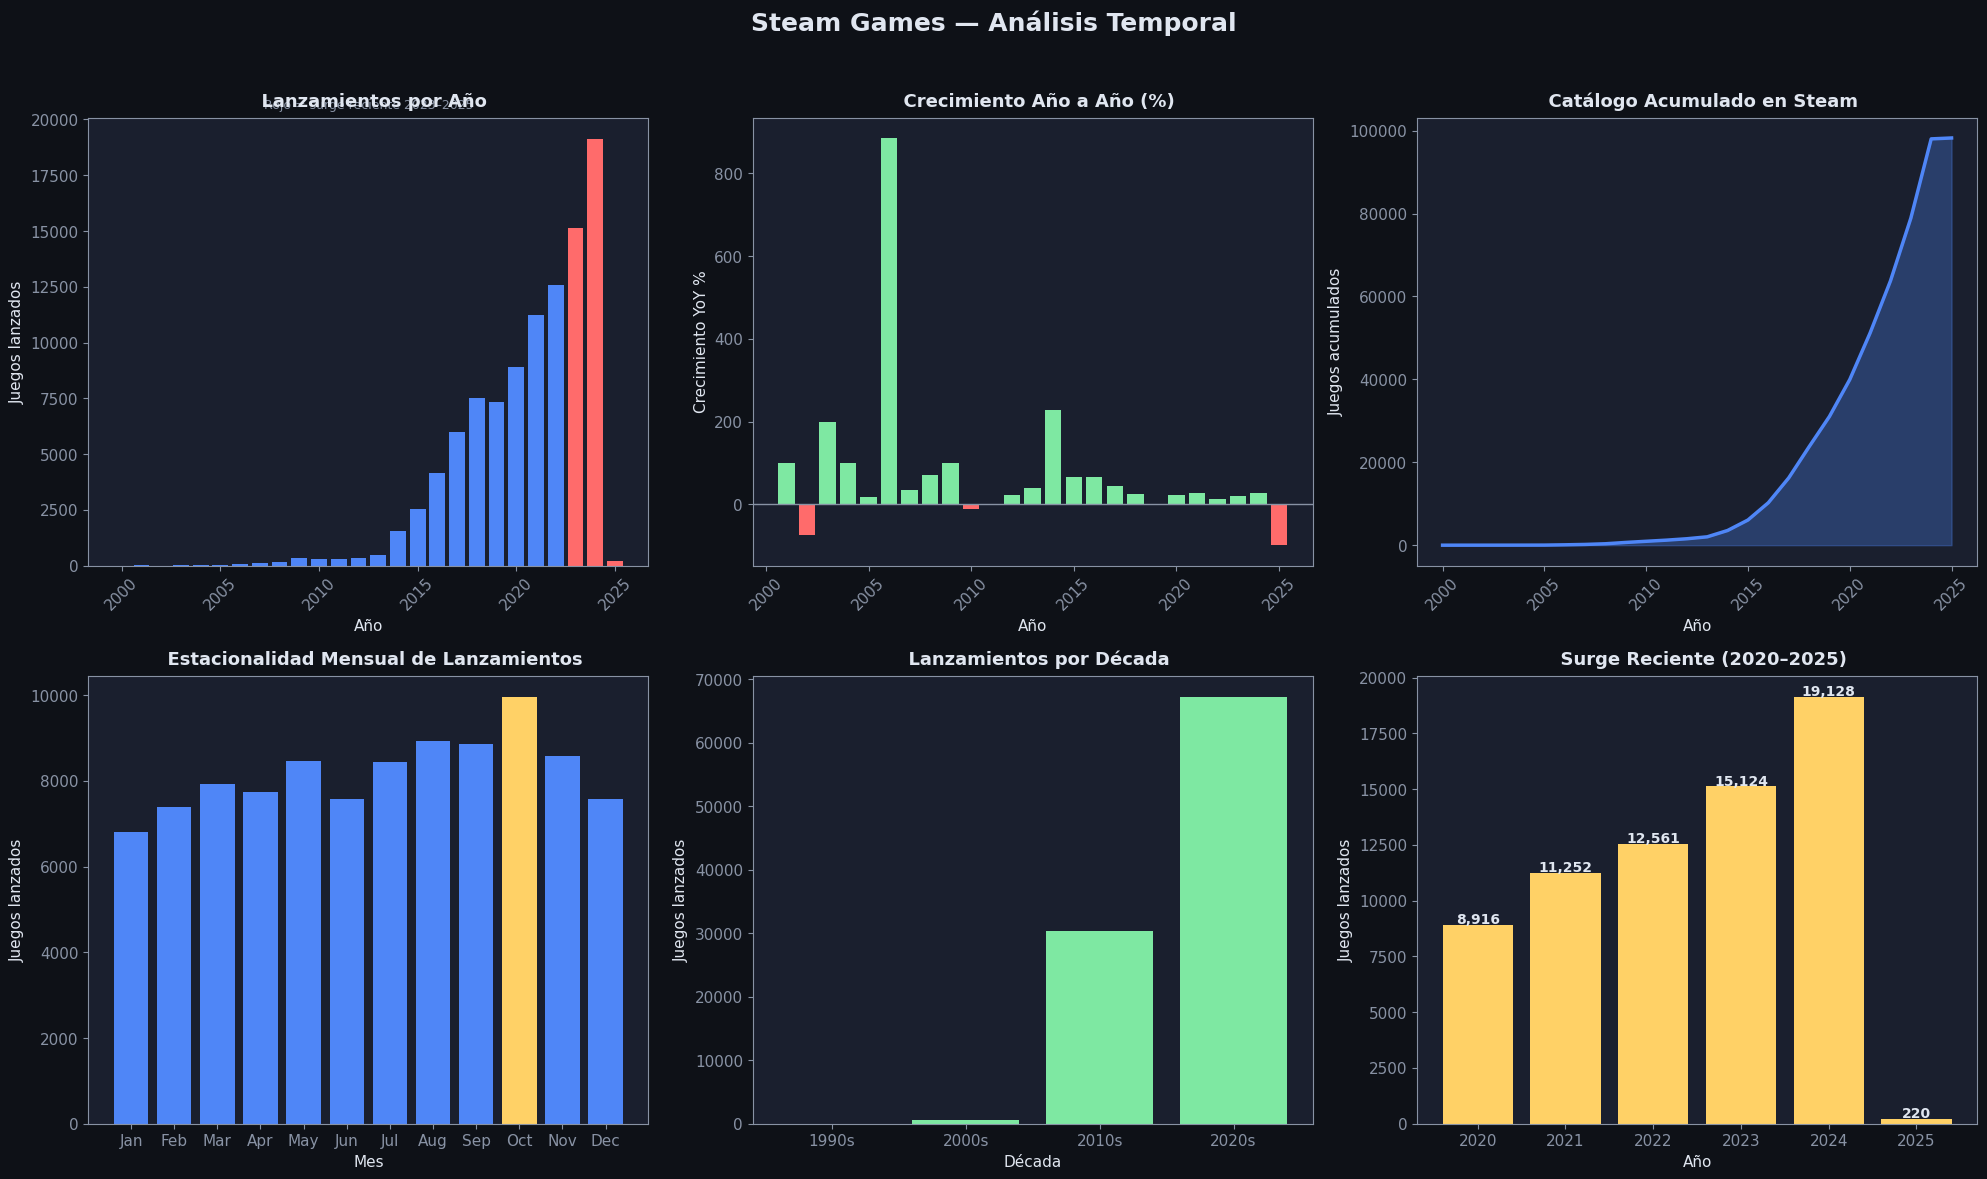

In [8]:
fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.patch.set_facecolor(DARK_BG)
fig2.suptitle('Steam Games — Análisis Temporal', fontsize=18, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
colors_yr = [ACCENT3 if y >= 2023 else ACCENT1 for y in year_counts.index]
ax.bar(year_counts.index, year_counts.values, color=colors_yr, width=0.8)
ax.set_xlabel('Año'); ax.set_ylabel('Juegos lanzados')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Lanzamientos por Año', 'Rojo = surge reciente 2023–2025')

ax = axes[0, 1]
yoy = year_counts.pct_change() * 100
yoy_clean = yoy.dropna()
colors_yoy = [ACCENT2 if v >= 0 else ACCENT3 for v in yoy_clean.values]
ax.bar(yoy_clean.index, yoy_clean.values, color=colors_yoy, width=0.8)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('Año'); ax.set_ylabel('Crecimiento YoY %')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Crecimiento Año a Año (%)')

ax = axes[0, 2]
cum = year_counts.cumsum()
ax.fill_between(cum.index, cum.values, alpha=0.3, color=ACCENT1)
ax.plot(cum.index, cum.values, color=ACCENT1, linewidth=2.5)
ax.set_xlabel('Año'); ax.set_ylabel('Juegos acumulados')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Catálogo Acumulado en Steam')

ax = axes[1, 0]
bar_clrs = [ACCENT4 if v == month_release.max() else ACCENT1 for v in month_release.values]
ax.bar([MONTH_NAMES[m-1] for m in month_release.index], month_release.values, color=bar_clrs)
ax.set_xlabel('Mes'); ax.set_ylabel('Juegos lanzados')
title_ax(ax, '  Estacionalidad Mensual de Lanzamientos')


ax = axes[1, 1]
decade_map = {y: f'{(y//10)*10}s' for y in df['release_year'].dropna().unique()}
df['decade'] = df['release_year'].map(decade_map)
dec_counts = df['decade'].value_counts().sort_index().dropna()
ax.bar(dec_counts.index, dec_counts.values, color=ACCENT2)
ax.set_xlabel('Década'); ax.set_ylabel('Juegos lanzados')
title_ax(ax, '  Lanzamientos por Década')

ax = axes[1, 2]
recent = year_counts[year_counts.index >= 2020]
ax.bar(recent.index.astype(str), recent.values, color=ACCENT4)
for i, (yr, val) in enumerate(zip(recent.index, recent.values)):
    ax.text(i, val + 50, f'{val:,}', ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Juegos lanzados')
title_ax(ax, '  Surge Reciente (2020–2025)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
##  Análisis de Géneros e Idiomas

Los géneros en Steam son etiquetas multivalor (un juego puede tener varios). Puntos clave:
- Indie y Action dominan ampliamente refleja el catálogo masivo de juegos indie que inundaron Steam post-2017.
- La mayoría de juegos tiene entre 1 y 3 géneros, con poca dispersión.
- English es el idioma más soportado por un margen enorme, seguido de Simplified Chinese y German.
- El soporte de idiomas ha crecido consistentemente año a año, señal de mayor internacionalización.

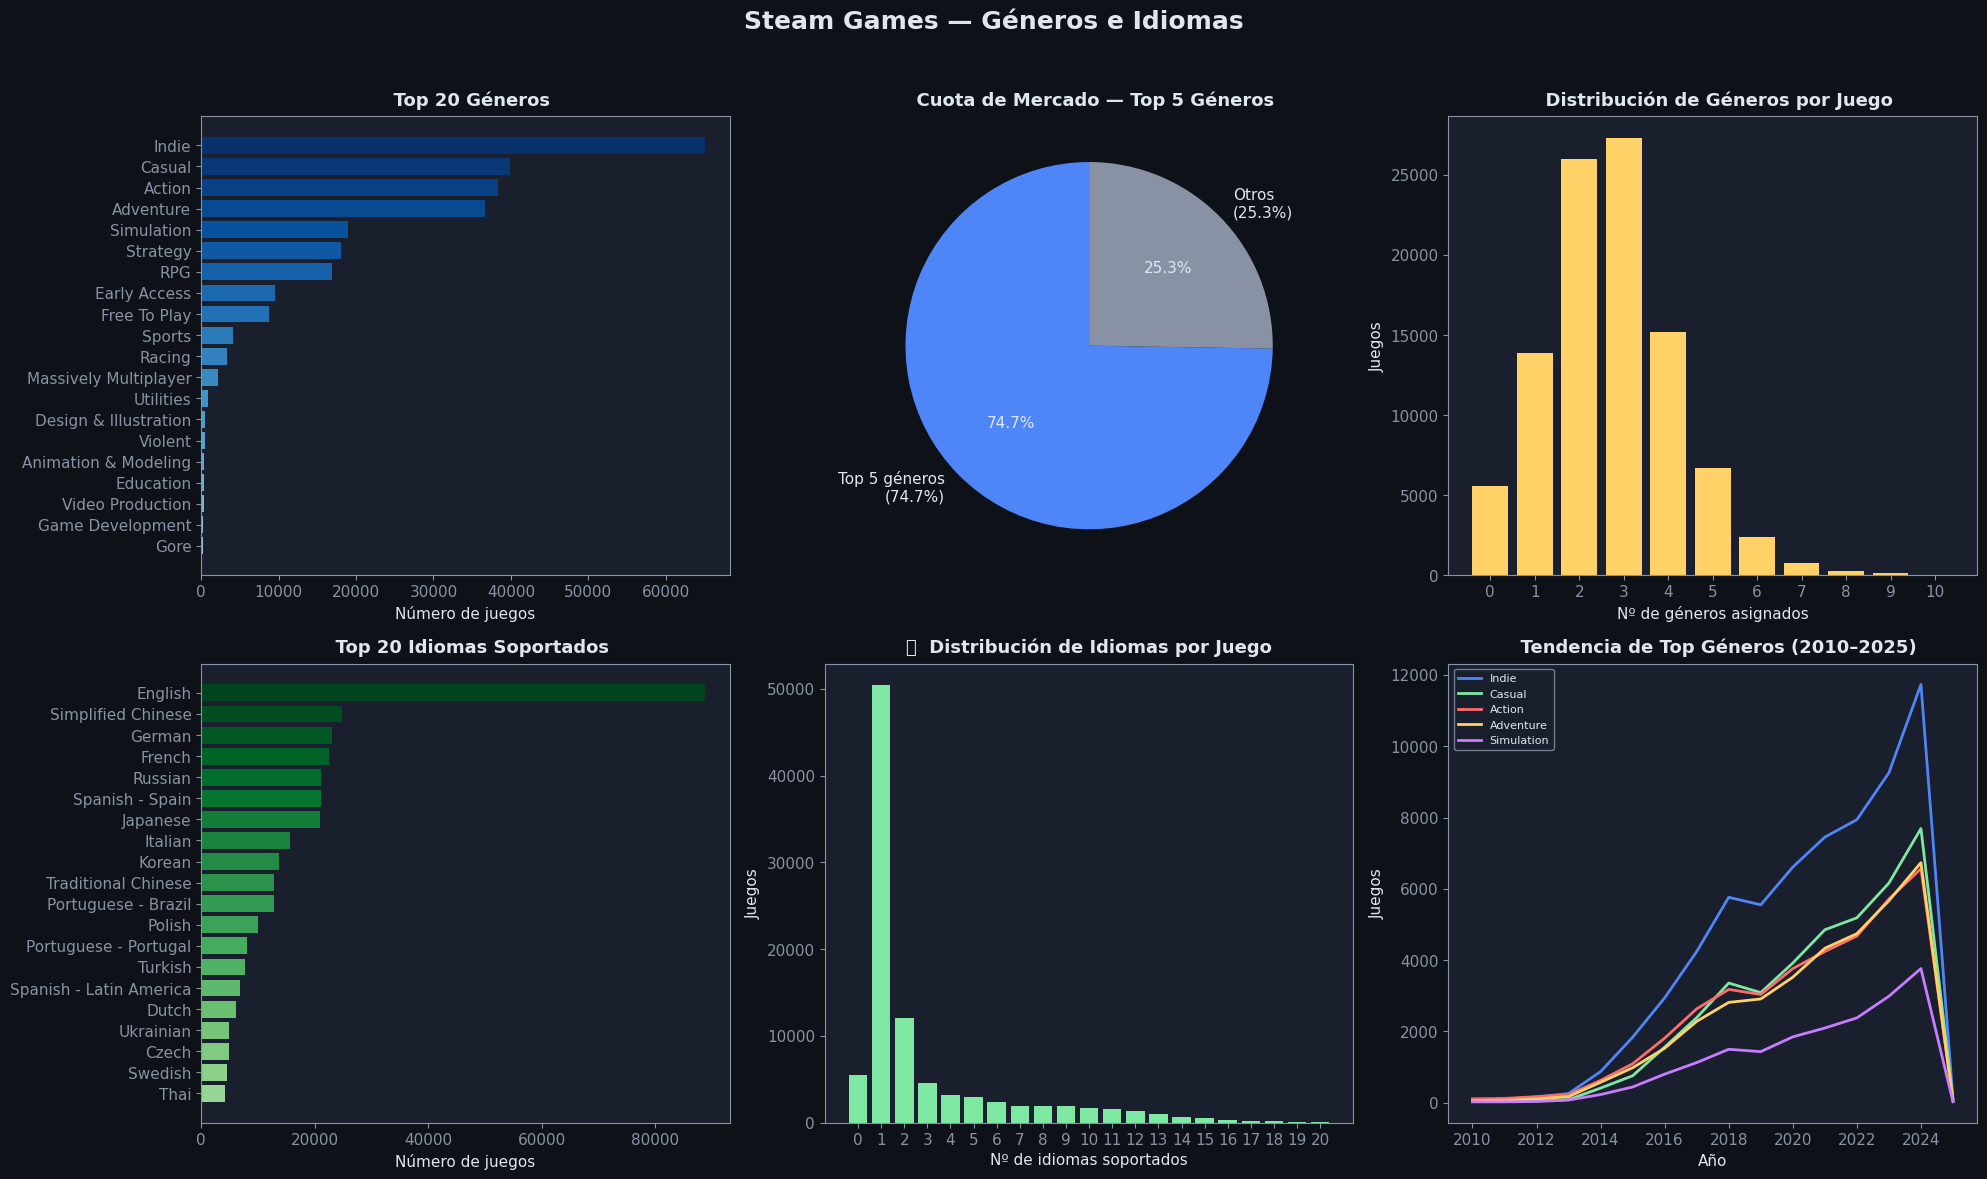

In [9]:
fig3, axes = plt.subplots(2, 3, figsize=(20, 12))
fig3.patch.set_facecolor(DARK_BG)
fig3.suptitle('Steam Games — Géneros e Idiomas', fontsize=18, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
cmap = plt.cm.Blues(np.linspace(0.4, 1.0, len(top_genres)))
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=cmap)
ax.set_xlabel('Número de juegos')
title_ax(ax, '  Top 20 Géneros')


ax = axes[0, 1]
top5_share = top_genres.head(5).sum() / genre_series.shape[0] * 100
rest_share  = 100 - top5_share
ax.pie([top5_share, rest_share],
       labels=[f'Top 5 géneros\n({top5_share:.1f}%)', f'Otros\n({rest_share:.1f}%)'],
       colors=[ACCENT1, MUTED], startangle=90, textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Cuota de Mercado — Top 5 Géneros')


ax = axes[0, 2]
gc = genre_counts_per_game.value_counts().sort_index()
gc = gc[gc.index <= 10]
ax.bar(gc.index.astype(str), gc.values, color=ACCENT4)
ax.set_xlabel('Nº de géneros asignados'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución de Géneros por Juego')


ax = axes[1, 0]
cmap2 = plt.cm.Greens(np.linspace(0.4, 1.0, len(top_langs)))
ax.barh(top_langs.index[::-1], top_langs.values[::-1], color=cmap2)
ax.set_xlabel('Número de juegos')
title_ax(ax, '  Top 20 Idiomas Soportados')


ax = axes[1, 1]
lc = df['supported_languages_count'].value_counts().sort_index()
lc = lc[lc.index <= 20]
ax.bar(lc.index.astype(str), lc.values, color=ACCENT2)
ax.set_xlabel('Nº de idiomas soportados'); ax.set_ylabel('Juegos')
title_ax(ax, '🗣️  Distribución de Idiomas por Juego')


ax = axes[1, 2]
top5 = top_genres.head(5).index.tolist()
genre_year = df.explode('genres_list')
genre_year = genre_year[genre_year['genres_list'].isin(top5)].dropna(subset=['release_year'])
genre_year = genre_year[genre_year['release_year'] >= 2010]
pivot = genre_year.groupby(['release_year', 'genres_list']).size().unstack(fill_value=0)
colors_t = [ACCENT1, ACCENT2, ACCENT3, ACCENT4, '#c77dff']
for i, g in enumerate(top5):
    if g in pivot.columns:
        ax.plot(pivot.index, pivot[g], label=g, color=colors_t[i], linewidth=2)
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Año'); ax.set_ylabel('Juegos')
title_ax(ax, '  Tendencia de Top Géneros (2010–2025)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
##  Análisis de Desarrolladores y Publishers

- El mercado está altamente fragmentado: la mayoría de developers solo tiene 1–2 juegos en el catálogo. Los grandes estudios son la minoría.
- Existe una fuerte correlación entre developer y publisher del mismo estudio  práctica común en el sector indie (self-publishing).
- Los top 10 publishers controlan una porción relativamente pequeña del catálogo total, lo que confirma la naturaleza long-tail del mercado Steam.

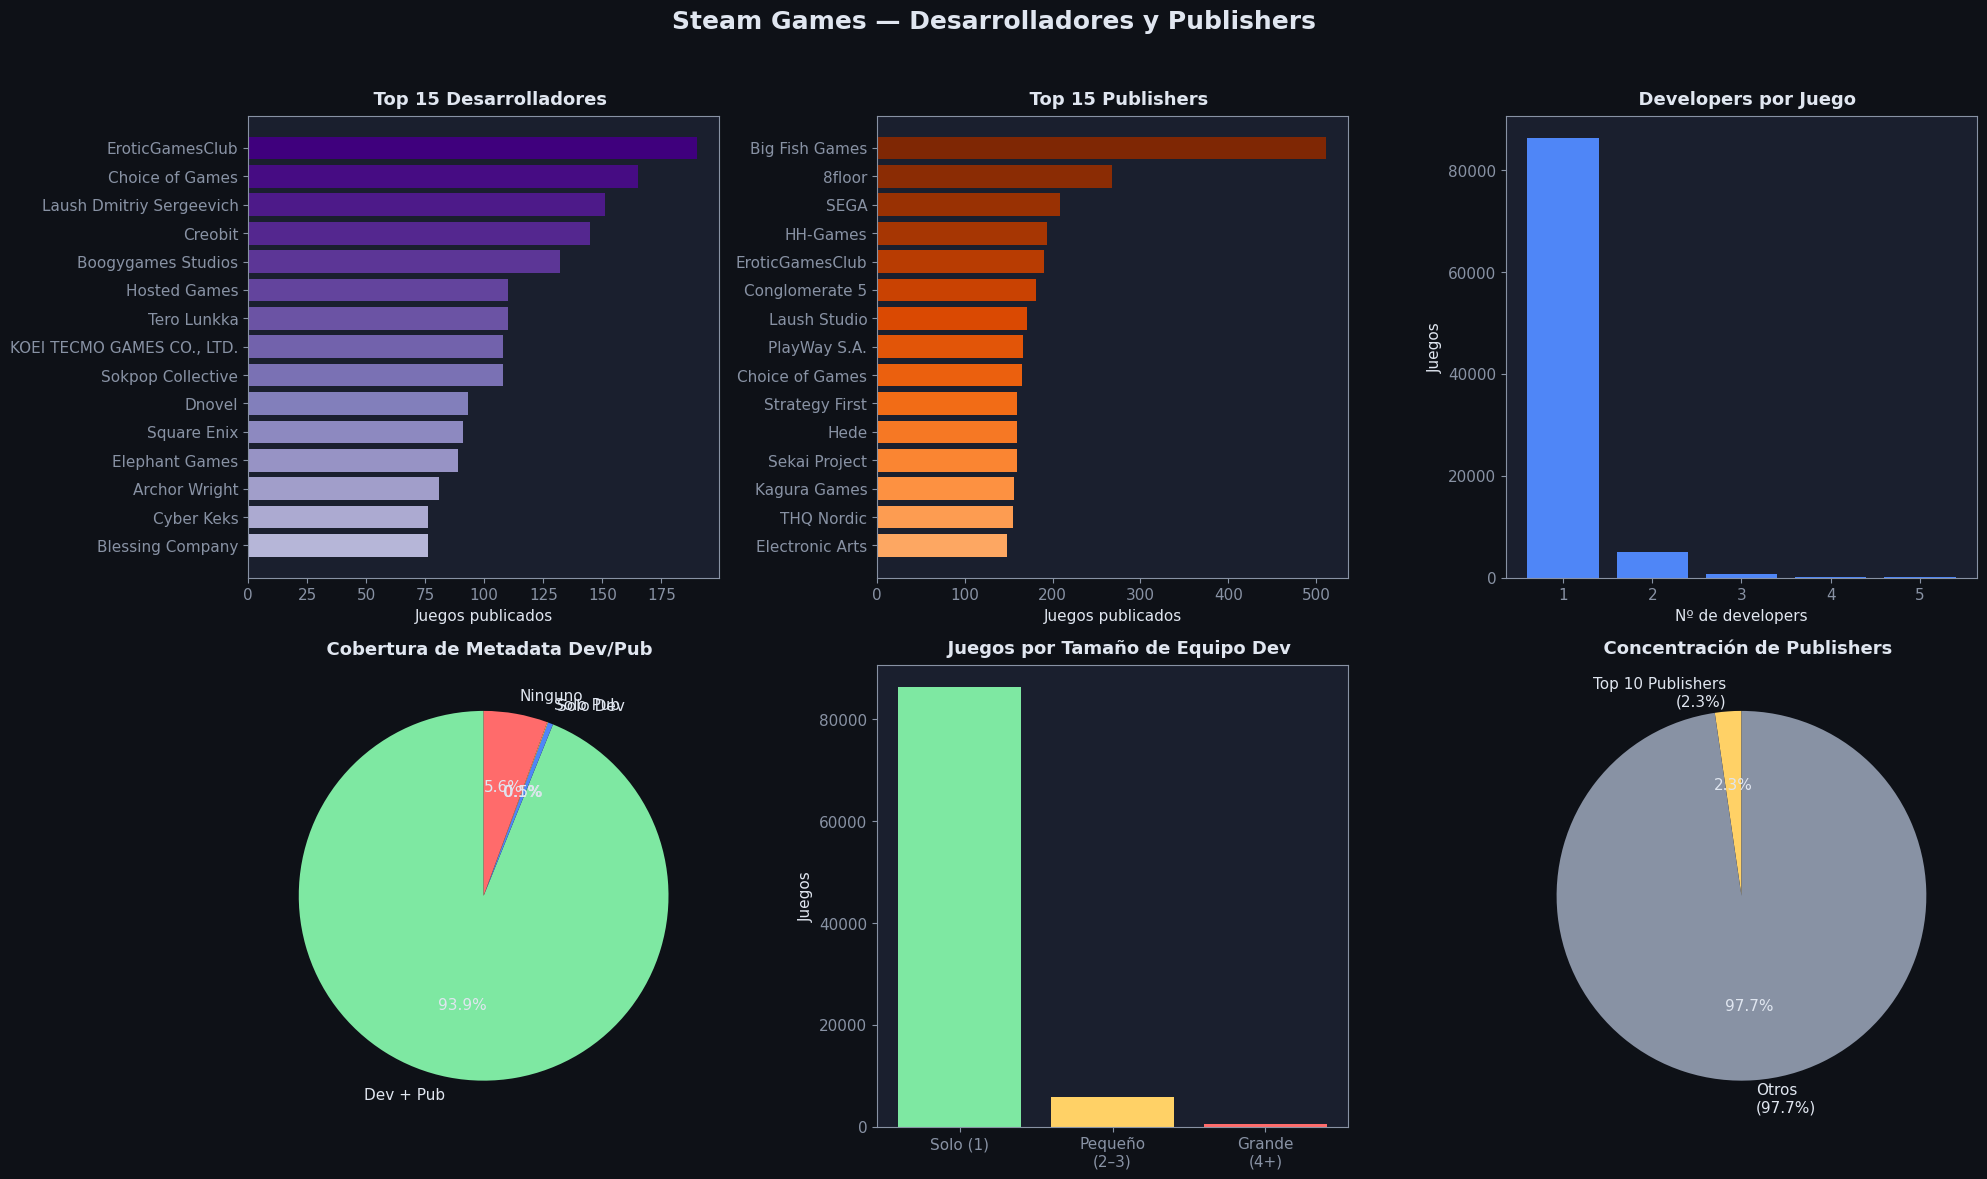

In [10]:
fig4, axes = plt.subplots(2, 3, figsize=(20, 12))
fig4.patch.set_facecolor(DARK_BG)
fig4.suptitle('Steam Games — Desarrolladores y Publishers', fontsize=18, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
cmap3 = plt.cm.Purples(np.linspace(0.4, 1.0, len(top_devs)))
ax.barh(top_devs.index[::-1], top_devs.values[::-1], color=cmap3)
ax.set_xlabel('Juegos publicados')
title_ax(ax, '  Top 15 Desarrolladores')

ax = axes[0, 1]
cmap4 = plt.cm.Oranges(np.linspace(0.4, 1.0, len(top_pubs)))
ax.barh(top_pubs.index[::-1], top_pubs.values[::-1], color=cmap4)
ax.set_xlabel('Juegos publicados')
title_ax(ax, '  Top 15 Publishers')

ax = axes[0, 2]
dc = games_per_dev.value_counts().sort_index()
dc = dc[dc.index <= 5]
ax.bar(dc.index.astype(str), dc.values, color=ACCENT1)
ax.set_xlabel('Nº de developers'); ax.set_ylabel('Juegos')
title_ax(ax, '  Developers por Juego')

ax = axes[1, 0]
both     = ((df['developers_count'] > 0) & (df['publishers_count'] > 0)).sum()
dev_only = ((df['developers_count'] > 0) & (df['publishers_count'] == 0)).sum()
pub_only = ((df['developers_count'] == 0) & (df['publishers_count'] > 0)).sum()
neither  = ((df['developers_count'] == 0) & (df['publishers_count'] == 0)).sum()
ax.pie([both, dev_only, pub_only, neither],
       labels=['Dev + Pub', 'Solo Dev', 'Solo Pub', 'Ninguno'],
       autopct='%1.1f%%', colors=[ACCENT2, ACCENT1, ACCENT4, ACCENT3],
       startangle=90, textprops={'color': TEXT})
title_ax(ax, '  Cobertura de Metadata Dev/Pub')

ax = axes[1, 1]
solo  = (games_per_dev == 1).sum()
small = ((games_per_dev >= 2) & (games_per_dev <= 3)).sum()
large = (games_per_dev > 3).sum()
ax.bar(['Solo (1)', 'Pequeño\n(2–3)', 'Grande\n(4+)'],
       [solo, small, large], color=[ACCENT2, ACCENT4, ACCENT3])
ax.set_ylabel('Juegos')
title_ax(ax, '  Juegos por Tamaño de Equipo Dev')

ax = axes[1, 2]
top10_pub  = top_pubs.head(10).sum()
total_pub  = pub_series.shape[0]
rest_pub   = total_pub - top10_pub
ax.pie([top10_pub, rest_pub],
       labels=[f'Top 10 Publishers\n({top10_pub/total_pub*100:.1f}%)',
               f'Otros\n({rest_pub/total_pub*100:.1f}%)'],
       colors=[ACCENT4, MUTED], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Concentración de Publishers')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
##  Correlaciones y Análisis Avanzado

- Existe una correlación positiva moderada entre el número de géneros y el número de idiomas soportados los juegos más elaborados (con más géneros) tienden a tener mayor soporte de idiomas.
- La riqueza de géneros por juego ha aumentado con el tiempo: los juegos recientes tienen más etiquetas de género en promedio.
- El soporte promedio de idiomas creció sostenidamente desde 2005, lo que indica una mayor internacionalización del mercado.
- La composición de géneros se ha mantenido relativamente estable entre eras, con Indie y Action siempre dominantes.

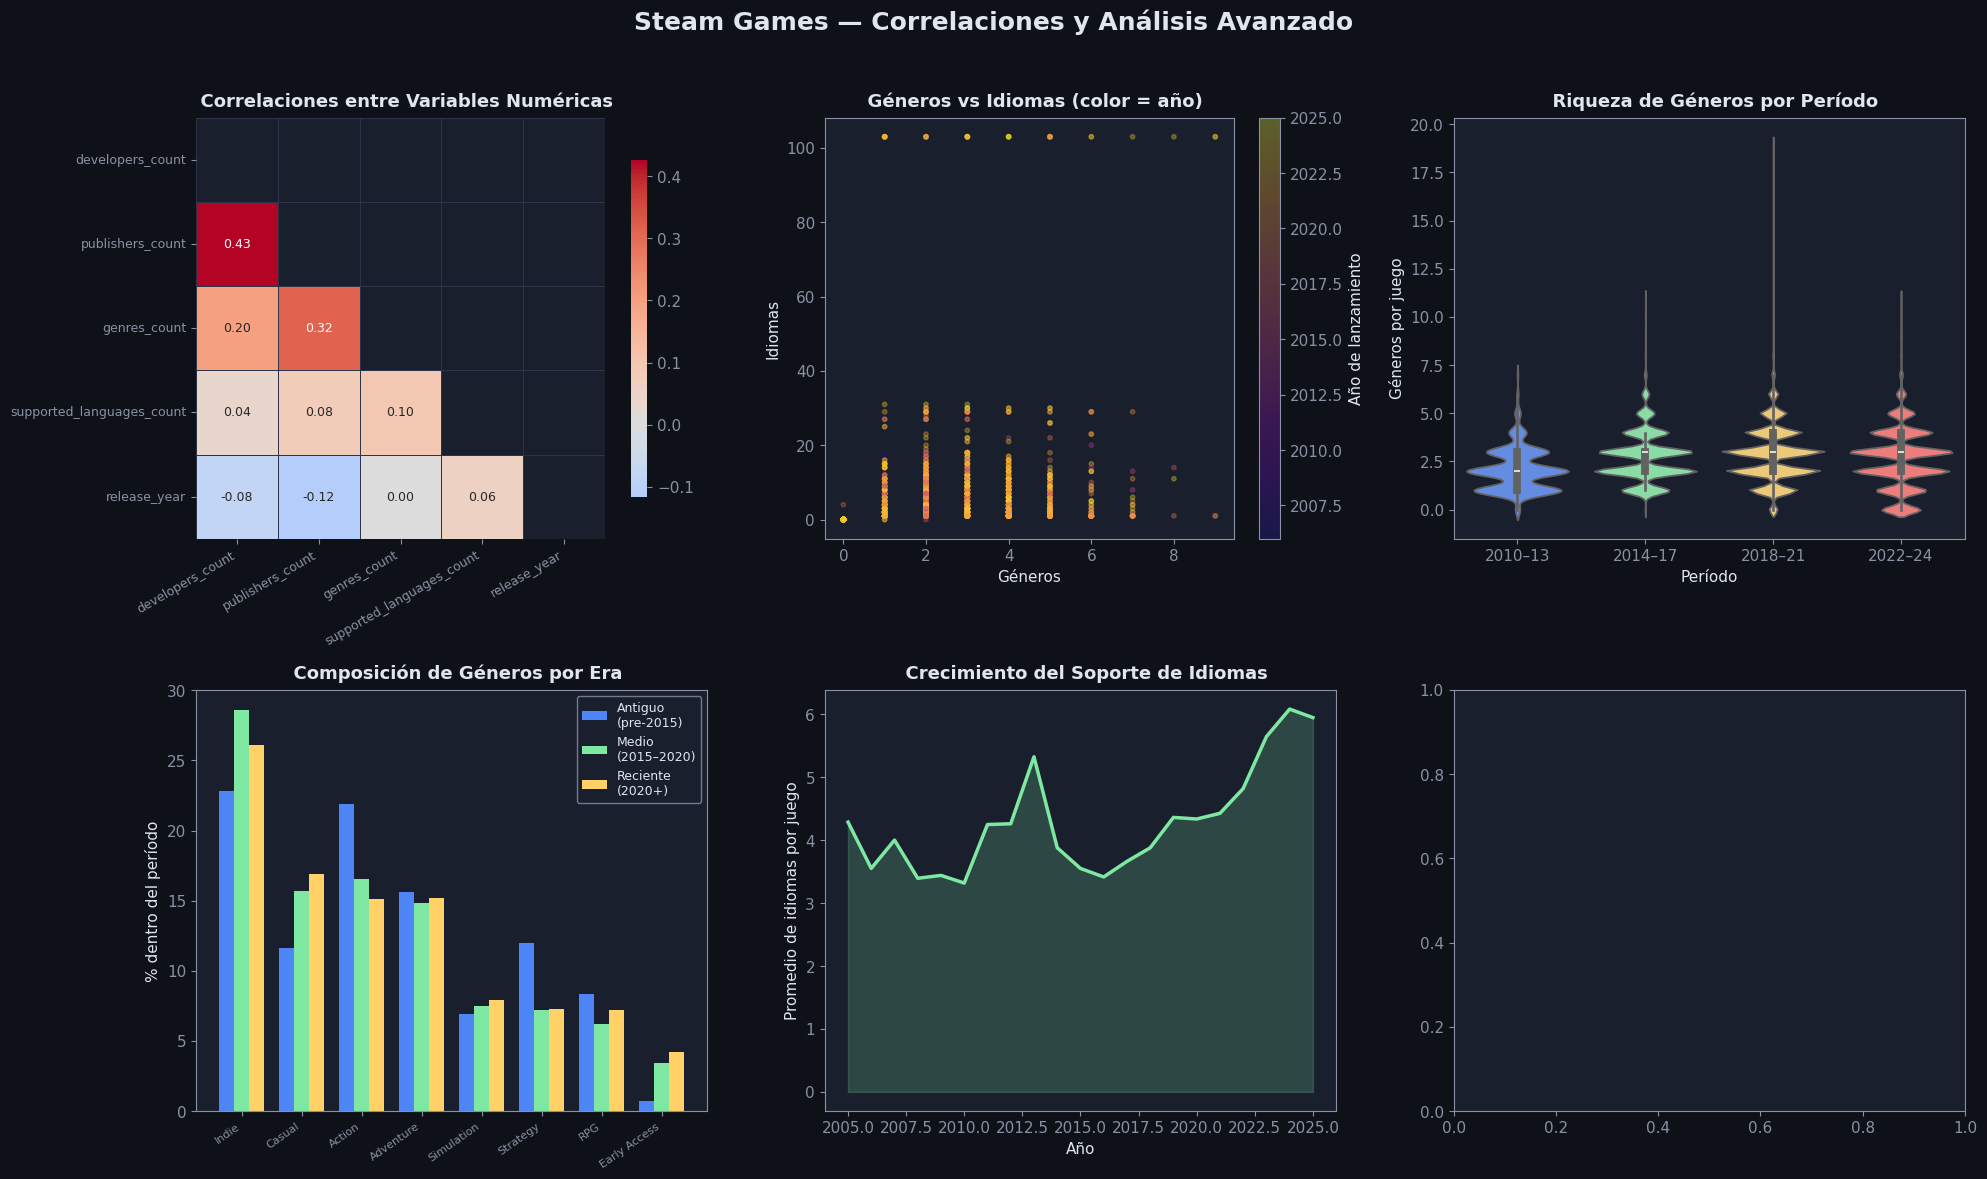

In [11]:
fig5, axes = plt.subplots(2, 3, figsize=(20, 12))
fig5.patch.set_facecolor(DARK_BG)
fig5.suptitle('Steam Games — Correlaciones y Análisis Avanzado', fontsize=18, fontweight='bold', color=TEXT, y=0.98)

ax = axes[0, 0]
num_cols = ['developers_count', 'publishers_count', 'genres_count', 'supported_languages_count', 'release_year']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#2d3348', cbar_kws={'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
title_ax(ax, '  Correlaciones entre Variables Numéricas')

ax = axes[0, 1]
sample_s = df.sample(min(3000, n_rows), random_state=42)
sc = ax.scatter(sample_s['genres_count'], sample_s['supported_languages_count'],
                alpha=0.3, s=10, c=sample_s['release_year'].fillna(2015), cmap='plasma')
plt.colorbar(sc, ax=ax, label='Año de lanzamiento')
ax.set_xlabel('Géneros'); ax.set_ylabel('Idiomas')
title_ax(ax, '  Géneros vs Idiomas (color = año)')

ax = axes[0, 2]
violin_df = df[(df['release_year'] >= 2010) & (df['release_year'] <= 2024)].copy()
violin_df['yr_bin'] = pd.cut(violin_df['release_year'], bins=[2009,2013,2017,2021,2024],
                              labels=['2010–13','2014–17','2018–21','2022–24'])
sns.violinplot(data=violin_df, x='yr_bin', y='genres_count', ax=ax,
               palette=[ACCENT1, ACCENT2, ACCENT4, ACCENT3], inner='box')
ax.set_xlabel('Período'); ax.set_ylabel('Géneros por juego')
title_ax(ax, '  Riqueza de Géneros por Período')

ax = axes[1, 0]
eras = {
    'Antiguo\n(pre-2015)': df[df['release_year'] < 2015],
    'Medio\n(2015–2020)':  df[(df['release_year'] >= 2015) & (df['release_year'] < 2020)],
    'Reciente\n(2020+)':   df[df['release_year'] >= 2020],
}
top8 = top_genres.head(8).index.tolist()
era_data = {}
for era, subdf in eras.items():
    gs = subdf.explode('genres_list')['genres_list']
    gs = gs[gs.isin(top8)]
    era_data[era] = gs.value_counts().reindex(top8, fill_value=0)
era_df = pd.DataFrame(era_data)
era_norm = era_df.div(era_df.sum()) * 100
x = np.arange(len(top8)); w = 0.25
for i, (col, clr) in enumerate(zip(era_norm.columns, [ACCENT1, ACCENT2, ACCENT4])):
    ax.bar(x + i*w, era_norm[col], width=w, label=col, color=clr)
ax.set_xticks(x + w); ax.set_xticklabels(top8, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% dentro del período')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Composición de Géneros por Era')

ax = axes[1, 1]
lang_yr = df.dropna(subset=['release_year'])
lang_yr = lang_yr[lang_yr['release_year'] >= 2005]
lang_mean = lang_yr.groupby('release_year')['supported_languages_count'].mean()
ax.plot(lang_mean.index, lang_mean.values, color=ACCENT2, linewidth=2.5)
ax.fill_between(lang_mean.index, lang_mean.values, alpha=0.2, color=ACCENT2)
ax.set_xlabel('Año'); ax.set_ylabel('Promedio de idiomas por juego')
title_ax(ax, '  Crecimiento del Soporte de Idiomas')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [12]:
ax = axes[1, 2]
ax.axis('off'); ax.set_facecolor(CARD_BG)
findings = [
    "  HALLAZGOS PRINCIPALES",
    "",
    f"1. {year_counts.idxmax():.0f} fue el año con más lanzamientos",
    f"   ({year_counts.max():,} juegos en un solo año).",
    "",
    f"2. '{top_genres.index[0]}' es el género dominante",
    f"   ({top_genres.iloc[0]:,} juegos, {top_genres.iloc[0]/genre_series.shape[0]*100:.1f}% del total).",
    "",
    f"3. '{top_langs.index[0]}' es el idioma más soportado",
    f"   en todo el catálogo.",
    "",
    f"4. {miss_pct['developers']:.0f}% de los juegos no tienen",
    f"   información de developer registrada.",
    "",
    f"5. El {(genre_counts_per_game<=3).mean()*100:.0f}% de juegos tiene ≤3 géneros.",
    "",
    f"6. Los Playtests representan el",
    f"   {df['is_playtest'].mean()*100:.1f}% del dataset.",
]
for i, line in enumerate(findings):
    clr = ACCENT4 if i == 0 else (ACCENT2 if line.startswith('   ') else TEXT)
    ax.text(0.04, 0.97 - i*0.056, line, transform=ax.transAxes,
            fontsize=9.5, color=clr, va='top',
            fontweight='bold' if i == 0 else 'normal')
    
findings

['  HALLAZGOS PRINCIPALES',
 '',
 '1. 2024 fue el año con más lanzamientos',
 '   (19,128 juegos en un solo año).',
 '',
 "2. 'Indie' es el género dominante",
 '   (65,024 juegos, 24.5% del total).',
 '',
 "3. 'English' es el idioma más soportado",
 '   en todo el catálogo.',
 '',
 '4. 6% de los juegos no tienen',
 '   información de developer registrada.',
 '',
 '5. El 74% de juegos tiene ≤3 géneros.',
 '',
 '6. Los Playtests representan el',
 '   5.4% del dataset.']

---
##  Conclusiones



### Próximos pasos
Este archivo es el **esqueleto del modelo de clasificación** cada fila es un juego y aquí se anclan todas las features. Al cruzar con los demás archivos se construye la tabla maestra de features por juego:

| Feature | Fuente | Clave de unión |
|---|---|---|
| `n_owners_public` | `purchased_games` | `gameid` |
| `usd_log`, `price_tier`, `has_price` | `prices` | `gameid` |
| `n_achievements`, `is_spam_game` | `achievements` | `gameid` |
| `avg_completion_rate` | `history` × `achievements` | `gameid` |
| `n_reviews`, `positive_ratio` | `reviews` | `gameid` |

- **Target de clasificación:** `is_popular` = top 25% de `n_owners_public` (o de `avg_completion_rate`). Definir el umbral en el notebook de feature engineering.
- **CS2 y juegos F2P:** cruzar `n_owners_public > umbral` con `has_price = False` de `prices` para detectar F2P. Evaluar si CS2 (gameid=730) debe excluirse del análisis por ser un outlier de penetración.
- **Géneros:** ¿qué géneros tienen mayor `n_owners_public`? ¿Mayor `positive_ratio` en reviews? Estas correlaciones enriquecen la interpretación del modelo.
- **Idiomas:** ¿hay correlación entre número de idiomas soportados y popularidad?


---
## Exportar dataset limpio

**Archivo generado:**
- `games_clean.csv` — una fila por juego con todas las features calculadas: `gameid`, `title`, `release_year`, `primary_genre`, `genres_count`, `developers_count`, `publishers_count`, `supported_languages_count`, `is_playtest`


In [13]:
# primary_genre: primer género de la lista
df['primary_genre'] = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

# Columnas escalares (sin las listas — no serializan bien en CSV)
cols_games = [
    'gameid', 'title', 'release_date', 'release_year',
    'primary_genre', 'genres_count',
    'developers_count', 'publishers_count',
    'supported_languages_count', 'is_playtest'
]
cols_games = [c for c in cols_games if c in df.columns]

df[cols_games].to_csv('Datos/games_clean.csv', index=False)

print(f'games_clean.csv : {len(df):,} juegos, {len(cols_games)} columnas')
print(f'  Géneros únicos   : {df["primary_genre"].nunique()}')
print(f'  is_playtest=True : {df["is_playtest"].sum():,}')
df[cols_games].head(3)


games_clean.csv : 98,248 juegos, 10 columnas
  Géneros únicos   : 28
  is_playtest=True : 5,294


,gameid,title,release_date,release_year,primary_genre,genres_count,developers_count,publishers_count,supported_languages_count,is_playtest
0,3281560,Horror Game To Play With Friends! Playtest,2024-10-21,2024,Unknown,0,0,0,0,True
1,3280930,Eternals' Path Playtest,2024-10-17,2024,Unknown,0,0,0,0,True
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,2024-10-13,2024,Unknown,0,0,0,0,True
